# 08 – Information-Theoretic Market States

## Motivation

Instead, market efficiency appears to be strongly associated with information-dynamics features such as:

- Max Drawdown
- Reversals
- Entropy
- Probability Range
- Trend

Furthermore, an Early Warning System demonstrated that market efficiency can be detected surprisingly early in a market's lifecycle.

However, all previous analyses assumed a binary framework:

- Efficient Markets
- Inefficient Markets

This raises a more fundamental question:

Are prediction markets naturally organized into different market states?

Rather than imposing labels, we allow the data to reveal its own structure.

---

## Research Question

Can information-dynamics features be used to identify distinct types of prediction markets?

---

## Core Hypothesis

Prediction markets do not form a homogeneous population.

Instead, they may exhibit different information-processing regimes characterized by distinct patterns of:

- Belief revision
- Information incorporation
- Consensus formation
- Uncertainty evolution

---

### Outcome Variables

For interpretation purposes:

- Abs Surprise
- Efficient Market Indicator

will be retained but **not used during clustering**.

---

## Methodology

### Feature Standardization

All variables will be standardized to ensure comparable scales.

$ z_i = \frac{x_i - \mu}{\sigma} $
---

### Dimensionality Reduction

Principal Component Analysis (PCA) will be used to:

- Reduce dimensionality
- Visualize market structure
- Identify dominant information-dynamics factors

The goal is to determine whether prediction markets naturally occupy distinct regions of feature space.

---

### Unsupervised Clustering

K-Means clustering will be applied using standardized information-dynamics features.

Several candidate values of:

$ K $
will be evaluated.

---

### Cluster Selection

Cluster quality will be evaluated using:

### Silhouette Score

$ S(i) = \frac{b(i)-a(i)} {\max(a(i),b(i))} $
where:

- $ a(i) $  is within-cluster distance
- $ b(i) $is nearest-cluster distance

The optimal number of clusters will maximize separation and cohesion.

---

### Market State Characterization

For each cluster we will compute:

- Mean Entropy
- Mean Drawdown
- Mean Reversals
- Mean Volatility
- Mean Abs Surprise

This allows economic interpretation of each market state.

---

## Expected Market States

Potential examples include:

### Fast Information Markets

Characteristics:

- High Drawdown
- High Reversals
- Low Entropy
- Low Forecast Error

---

### Consensus Markets

Characteristics:

- Moderate Drawdown
- Low Entropy
- Stable Belief Evolution

---

### Chaotic Markets

Characteristics:

- High Entropy
- High Volatility
- Poor Forecast Accuracy

---

### Anchored Markets

Characteristics:

- Low Drawdown
- Low Reversals
- Limited Information Updating

---

## Evaluation

After clustering, we will investigate:

### Efficiency by Cluster

$ E[AbsSurprise | Cluster] $

to determine whether certain market states are naturally more efficient than others.

---


## Final Objective

Identify and characterize distinct information-theoretic market states using unsupervised learning techniques.

If successful, this analysis may reveal latent market regimes that explain why some prediction markets consistently outperform others.

In [1]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
df_model_v2 = pd.read_csv("../data/processed/df_model_v2.csv")


In [4]:
# PCA + clustering 
features = [
    "realized_volatility",
    "probability_range",
    "trend",
    "max_drawdown",
    "reversals",
    "shannon_entropy",
    "skewness",
    "kurtosis",
    "autocorrelation"
]

df = df_model_v2.copy()
X = df[features]
# Pipeline
preprocess = Pipeline([("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())])
X_scaled = preprocess.fit_transform(X)
# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

pca_df = pd.DataFrame(X_pca,columns=["PC1", "PC2"])
pca_df["market_id"] = df["market_id"].values
pca_df["abs_surprise"] = df["abs_surprise"].values


Explained variance ratio: [0.28110848 0.1699732 ]
Total explained variance: 0.4510816730996864


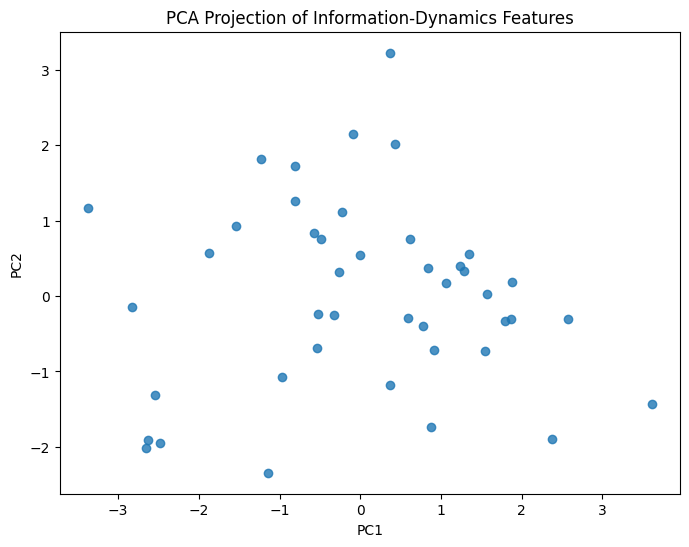

In [6]:
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    
    alpha=0.8
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of Information-Dynamics Features")
plt.show()

In [9]:
silhouette_results = []

for k in range(2, 7): 
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_results.append({"k": k, "silhouette_score": score})

silhouette_df = pd.DataFrame(silhouette_results)

silhouette_df

,k,silhouette_score
0,2,0.225678
1,3,0.178330
2,4,0.186254
3,5,0.222815
4,6,0.216674


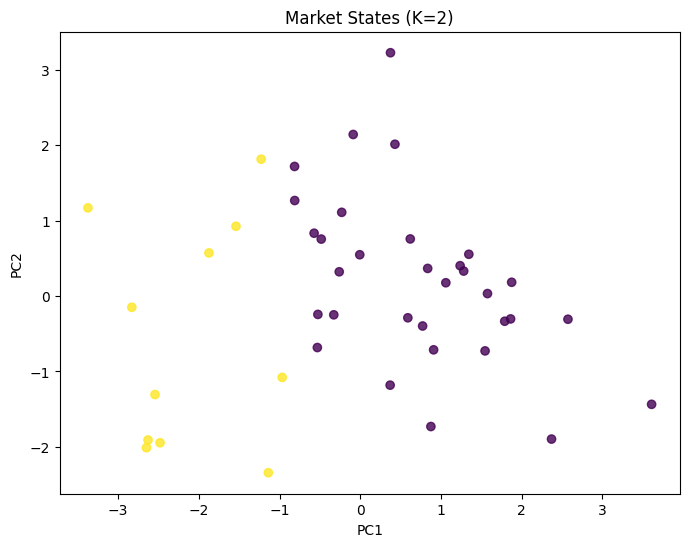

In [10]:
# Create clusters
kmeans = KMeans(n_clusters=2,random_state=42,n_init=20)
df["cluster"] = kmeans.fit_predict(X_scaled)
pca_df["cluster"] = df["cluster"]

plt.figure(figsize=(8,6))

plt.scatter(pca_df["PC1"],pca_df["PC2"],c=pca_df["cluster"],alpha=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Market States (K=2)")
plt.show()

In [11]:
df.groupby("cluster")[features].mean()

,realized_volatility,probability_range,trend,max_drawdown,reversals,shannon_entropy,skewness,kurtosis,autocorrelation
cluster,,,,,,,,,
0,0.634124,0.617969,0.003603,0.870148,702.843750,0.181319,0.346030,315.511425,-0.056202
1,0.087765,0.218455,0.000740,0.447587,96.727273,0.568352,-0.851877,79.586079,-0.216268


In [13]:
df.groupby("cluster")["abs_surprise"].agg(["count","mean","median", 'std'])

,count,mean,median,std
cluster,,,,
0,32,0.040422,0.00525,0.107889
1,11,0.340091,0.43500,0.245536


Prediction markets naturally organize into distinct information-processing regimes.

## Key Insight: Two Information-Processing Regimes

Unsupervised clustering revealed that prediction markets naturally organize into two distinct information-processing regimes.

### Regime 1 — Information Processing Markets

Characteristics:

- High Drawdown
- High Reversals
- High Probability Range
- Low Entropy

Performance:

- Mean Abs Surprise = 0.040
- Median Abs Surprise = 0.005

These markets actively revise beliefs, rapidly incorporate information, and ultimately converge to highly accurate forecasts.

---

### Regime 2 — Anchored / Noisy Markets

Characteristics:

- Low Drawdown
- Low Reversals
- Low Probability Range
- High Entropy

Performance:

- Mean Abs Surprise = 0.340
- Median Abs Surprise = 0.435

These markets exhibit limited belief updating, higher uncertainty, and substantially worse forecast accuracy.

---

### Main Finding

Prediction market efficiency appears to be driven by the dynamics of information incorporation rather than the market topic itself.

Markets that frequently update beliefs, aggressively correct mistakes, and exhibit lower entropy form a distinct regime associated with dramatically lower forecast error.